# Courant (CFL) Zahlen Analyse

Berechnung der Courant-Zahl aus den Simulationsergebnissen des Wärmetransports in der Grundwasserströmung.

In [73]:
import numpy as np
import pyvista as pv
from helper import calculate_wedge_base_inradius

In [74]:
# Optional: Für statische Plots in Notebooks
pv.set_jupyter_backend('static')

## 1. Mesh laden

In [75]:
# VTU-Datei laden
mesh = pv.read("geothermal_doublet_ts_518_t_1262304000.000000.vtu")
print(f"Anzahl der Zellen: {mesh.n_cells}")
print(f"Anzahl der Punkte: {mesh.n_points}")
print(f"Zelltypen: {np.unique(mesh.celltypes)}")

Anzahl der Zellen: 1552
Anzahl der Punkte: 1668
Zelltypen: [13]


## 2. Innenradius für jedes Element berechnen

In [76]:
# Innenradius der Dreiecksbasis berechnen
inradii = calculate_wedge_base_inradius(mesh)
print(f"Anzahl der berechneten Innenradien: {len(inradii)}")
print(f"Minimaler Innenradius: {np.min(inradii):.4f} m")
print(f"Maximaler Innenradius: {np.max(inradii):.4f} m")
print(f"Mittlerer Innenradius: {np.mean(inradii):.4f} m")

# Charakteristische Länge (2 * Innenradius) als Zelldaten hinzufügen
mesh.cell_data["char_length"] = 2 * inradii

Anzahl der berechneten Innenradien: 1552
Minimaler Innenradius: 0.3386 m
Maximaler Innenradius: 190.9432 m
Mittlerer Innenradius: 34.7755 m


## 3. Transportgeschwindigkeit aus Darcy-Geschwindigkeit berechnen

Die Transportgeschwindigkeit (Porengeschwindigkeit) berechnet sich aus der Darcy-Geschwindigkeit durch:

$$v_{transport} = \frac{v_{Darcy}}{\phi}$$

wobei $\phi$ die Porosität ist.

In [77]:
# Verfügbare Datenfelder anzeigen
print("Verfügbare cell_data Felder:")
print(mesh.cell_data.keys())
print("\nVerfügbare point_data Felder:")
print(mesh.point_data.keys())

# Porosität definieren (einheitlich für alle Elemente)
porosity = 0.2  # Beispielwert, bitte anpassen falls nötig

# Darcy-Geschwindigkeit aus den Daten extrahieren
# Prüfe ob es in cell_data oder point_data ist
if "darcy_velocity" in mesh.cell_data:
    darcy_velocity = mesh.cell_data["darcy_velocity"]
    print(f"\nDarcy-Geschwindigkeit gefunden in cell_data")
elif "darcy_velocity" in mesh.point_data:
    darcy_velocity = mesh.point_data["darcy_velocity"]
    print(f"\nDarcy-Geschwindigkeit gefunden in point_data")
    # Interpoliere von Punktdaten zu Zelldaten
    darcy_velocity = mesh.point_data_to_cell_data()["darcy_velocity"]
    print("Interpoliert zu cell_data")
else:
    raise KeyError("darcy_velocity nicht in mesh gefunden!")

print(f"Form der Darcy-Geschwindigkeit: {darcy_velocity.shape}")

# Betrag der Darcy-Geschwindigkeit berechnen
darcy_velocity_magnitude = np.linalg.norm(darcy_velocity, axis=1)

# Transportgeschwindigkeit berechnen (v_transport = v_darcy / porosity)
transport_velocity = darcy_velocity_magnitude / porosity

print(f"\nDarcy-Geschwindigkeit:")
print(f"  Minimum: {np.min(darcy_velocity_magnitude):.6e} m/s")
print(f"  Maximum: {np.max(darcy_velocity_magnitude):.6e} m/s")
print(f"  Mittelwert: {np.mean(darcy_velocity_magnitude):.6e} m/s")

print(f"\nTransportgeschwindigkeit (Porosität = {porosity}):")
print(f"  Minimum: {np.min(transport_velocity):.6e} m/s")
print(f"  Maximum: {np.max(transport_velocity):.6e} m/s")
print(f"  Mittelwert: {np.mean(transport_velocity):.6e} m/s")

# Als Zelldaten hinzufügen
mesh.cell_data["transport_velocity"] = transport_velocity

Verfügbare cell_data Felder:
['char_length']

Verfügbare point_data Felder:
['darcy_velocity', 'pressure', 'temperature']

Darcy-Geschwindigkeit gefunden in point_data
Interpoliert zu cell_data
Form der Darcy-Geschwindigkeit: (1552, 3)

Darcy-Geschwindigkeit:
  Minimum: 2.166683e-09 m/s
  Maximum: 1.436682e-04 m/s
  Mittelwert: 4.701285e-06 m/s

Transportgeschwindigkeit (Porosität = 0.2):
  Minimum: 1.083341e-08 m/s
  Maximum: 7.183410e-04 m/s
  Mittelwert: 2.350642e-05 m/s


## 4. CFL-Zahl berechnen

Die Courant-Friedrichs-Lewy (CFL) Zahl ist definiert als:

$$CFL = \frac{v \cdot \Delta t}{\Delta x}$$

wobei:
- $v$ = Transportgeschwindigkeit [m/s]
- $\Delta t$ = Zeitschrittweite [s]
- $\Delta x$ = charakteristische Länge (2 × Innenradius) [m]

In [78]:
# Zeitschrittweite definieren (Beispielwert)
dt = 86400.0*10  # Zeitschrittweite in Sekunden (10 Tage)
dt = 2592000.0  # Zeitschrittweite in Sekunden (30 Tage)

# CFL-Zahl für jedes Element berechnen
# CFL = (v * dt) / dx
cfl_number = (transport_velocity * dt) / mesh.cell_data["char_length"]

print(f"Zeitschrittweite: {dt} s ({dt/86400:.1f} Tage)")
print(f"\nCFL-Zahlen:")
print(f"  Minimum: {np.min(cfl_number):.6f}")
print(f"  Maximum: {np.max(cfl_number):.6f}")
print(f"  Mittelwert: {np.mean(cfl_number):.6f}")
print(f"  Median: {np.median(cfl_number):.6f}")

# Als Zelldaten hinzufügen
mesh.cell_data["CFL"] = cfl_number

# Anzahl der Elemente mit CFL > 1 (kritischer Bereich)
critical_cells = np.sum(cfl_number > 1.0)
print(f"\nAnzahl der Elemente mit CFL > 1: {critical_cells} ({100*critical_cells/len(cfl_number):.2f}%)")

Zeitschrittweite: 2592000.0 s (30.0 Tage)

CFL-Zahlen:
  Minimum: 0.000075
  Maximum: 2749.109189
  Mittelwert: 44.257546
  Median: 0.245045

Anzahl der Elemente mit CFL > 1: 558 (35.95%)


## 5. Visualisierung der CFL-Zahlen

Beide Darstellungen nebeneinander: Links die kontinuierliche CFL-Verteilung (logarithmisch), rechts die kategorische Einteilung in kritische und unkritische Bereiche.

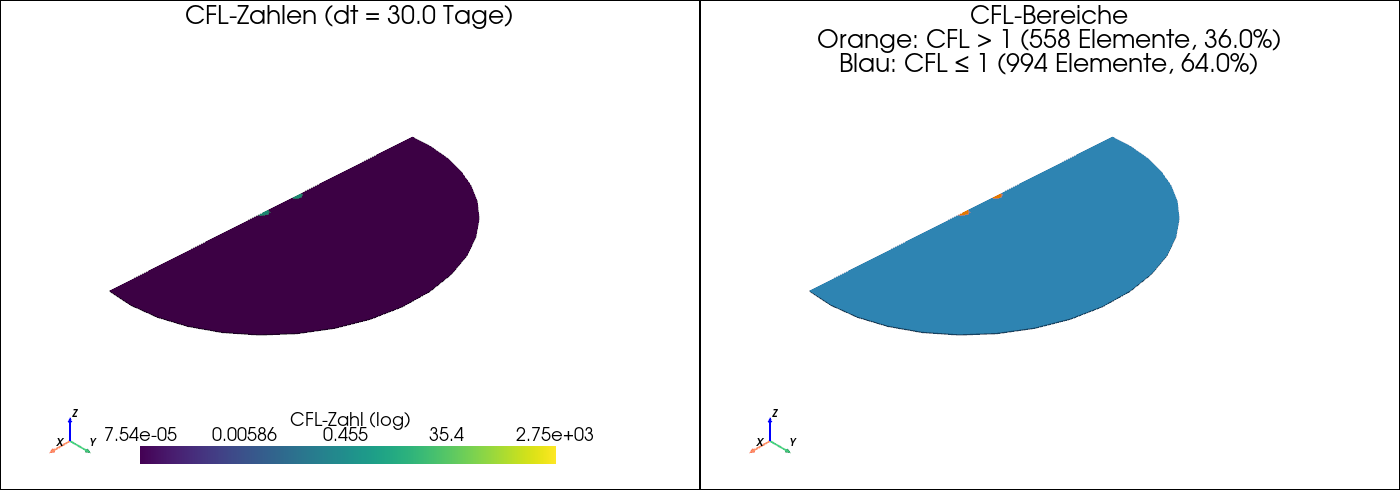

In [79]:
# Erstelle ein kategorisches Feld für CFL-Bereiche
cfl_category = (cfl_number > 1.0).astype(int)
mesh.cell_data["CFL_category"] = cfl_category

# Erstelle Plotter mit zwei Subplots nebeneinander und reduzierter Höhe
plotter = pv.Plotter(shape=(1, 2), window_size=[1400, 490])

# Links: CFL-Zahlen mit logarithmischer Farbskala
plotter.subplot(0, 0)
plotter.add_mesh(
    mesh,
    scalars="CFL",
    cmap="viridis",
    log_scale=True,
    show_edges=False,
    scalar_bar_args={
        'title': 'CFL-Zahl (log)',
        'vertical': False,
        'n_labels': 5,
        'height': 0.1,
        'position_x': 0.2,
        'position_y': 0.05
    }
)
plotter.add_text(
    f"CFL-Zahlen (dt = {dt/86400:.1f} Tage)",
    position="upper_edge",
    font_size=10
)
plotter.show_axes()

# Rechts: CFL-Bereiche (kategorisch)
plotter.subplot(0, 1)
plotter.add_mesh(
    mesh,
    scalars="CFL_category",
    cmap=["#3498db", "#ff8c00"],  # Blau für CFL<=1, Orange für CFL>1
    show_edges=False,
    show_scalar_bar=False
)
plotter.add_text(
    f"CFL-Bereiche\n"
    f"Orange: CFL > 1 ({critical_cells} Elemente, {100*critical_cells/len(cfl_number):.1f}%)\n"
    f"Blau: CFL ≤ 1 ({len(cfl_number)-critical_cells} Elemente, {100*(len(cfl_number)-critical_cells)/len(cfl_number):.1f}%)",
    position="upper_edge",
    font_size=10
)
plotter.show_axes()

# Zeige beide Plots
plotter.show()